## Dimensionality Reduction

### PCA

### NMF

### ICA

## The HR diagram

In [ ]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

import pandas as pd
df_stars = pd.read_csv("stars.csv")
df_stars


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


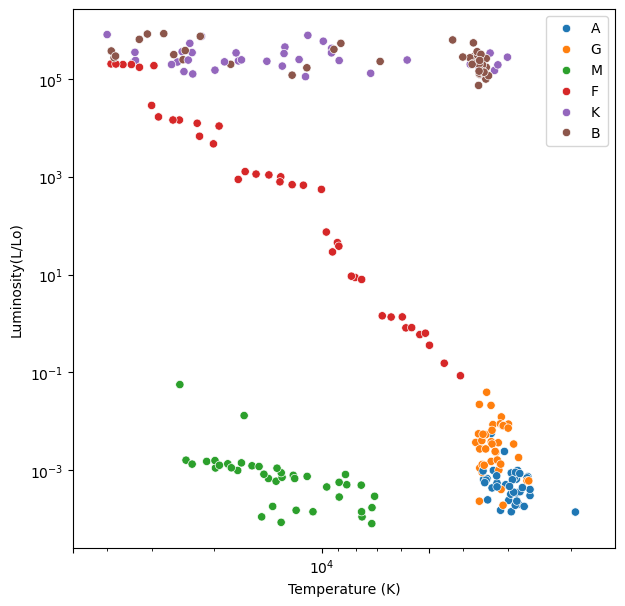

[[ 2.09892192e-02  9.99778551e-01  1.51672530e-03 -4.06568779e-05
  -1.38275392e-07  3.20160293e-06]
 [ 9.99737568e-01 -2.09743944e-02 -9.20988068e-03 -1.91786135e-04
   5.96115332e-05 -8.19054565e-05]]
[3.22101609e+10 7.70991694e+07]
Expained fractional variance of data encapsulated in the eigenvalues: [0.99760631 0.0023879 ]


Text(0, 0.5, 'Principal Component 2')

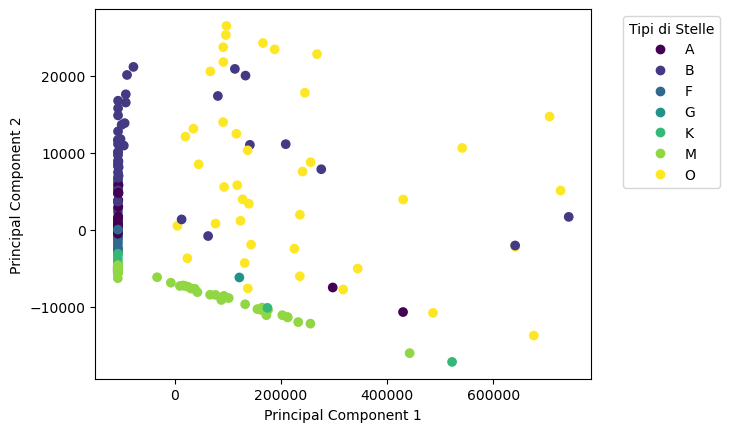

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

le = LabelEncoder()
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
df_stars['Spectral Class'] = le.fit_transform(df_stars['Spectral Class'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_

import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='tab10')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()


#preparo input per PCA
X = df_stars.select_dtypes(include='number')

'''
print(df_stars)
print(X)
'''

pca = PCA(n_components=2, svd_solver='randomized').fit(X) #a PCA guarda il tuo dataset, studia la forma della nuvola di punti, calcola il centro esatto, 
#le varianze e trova le direzioni migliori (gli autovettori) per schiacciare i dati.

transf_data = pca.transform(X) #applica per davvero la reduction e proietta i dati sugli autovettori calcolati, l'asse principale è quello con autovalore maggiore

#attributi con _ sono valori imparati dal modello durante il fit
eigenvectors = pca.components_                      
print(eigenvectors)
variance = pca.explained_variance_
print(variance)
variance_percent = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(variance_percent))

data = pca.inverse_transform(transf_data)

scatter = plt.scatter(transf_data[:,0],transf_data[:,1],c=df_stars['Spectral Class'],cmap='viridis')
plt.legend(handles=scatter.legend_elements()[0], labels=list(class_names), 
           title="Tipi di Stelle", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')



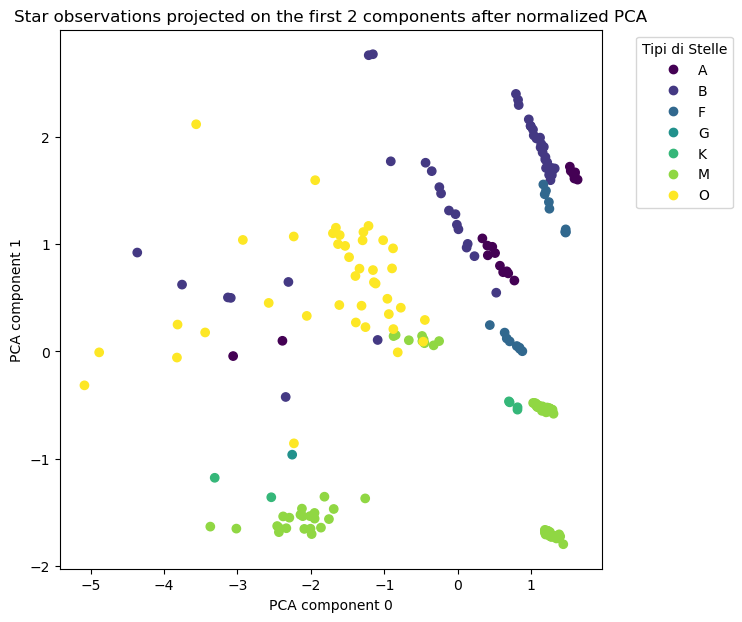

In [3]:
#apply standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=2, svd_solver='randomized')
projected_stars = pca.fit_transform(X)

fig = plt.figure(figsize=(7, 7))
fig = plt.scatter(projected_stars[:,0],projected_stars[:,1],c=df_stars['Spectral Class'],cmap='viridis')
plt.legend(handles=scatter.legend_elements()[0], labels=list(class_names), 
           title="Tipi di Stelle", bbox_to_anchor=(1.05, 1), loc='upper left')
#sns.scatterplot(x=projected_stars[:,0], y=projected_stars[:,1], hue=labels)
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1")


plt.title("Star observations projected on the first 2 components after normalized PCA")
plt.show()